In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

df = pd.read_csv('data/processed/listings_segmented.csv')
print(f'Loaded: {df.shape[0]:,} listings with {df.segment.nunique()} segments')

Loaded: 58,736 listings with 3 segments


### Data Preparation for Modeling

In [2]:
# Target: number_of_reviews as demand proxy

# Features for demand prediction
feature_cols = [
    # Property features
    'accommodates',
    'bedrooms',
    'bathrooms',
    'beds',
    'beds_per_bedroom',
    'bathrooms_per_bedroom',
    'capacity_per_bedroom',
    'property_type_encoded',
    # Pricing features
    'price',
    'price_per_person',
    'price_per_bedroom',
    'price_per_bed',
    'neighborhood_median_price',
    'price_vs_neighborhood',
    # Review & Reputation features
    'number_of_reviews_ltm',  
    'number_of_reviews_l30d',  
    'reviews_per_month', 
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'avg_review_score',
    # Host Qaulity
    'host_is_superhost',
    'host_quality_score',
    'is_professional_host',
    'host_listings_count',
    'host_total_listings_count',
    'calculated_host_listings_count',
    'host_response_rate',
    'host_acceptance_rate',
    # Availability & Booking patterns
    'minimum_nights',
    'minimum_nights_avg_ntm',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365',
    'availability_rate',
    'is_highly_available',
    'booking_rate_proxy',
    'instant_bookable_encoded',
    # Amenities
    'amenity_count',
    'essential_amenity_count',
    'has_pool',
    'has_hot_tub',
    'has_gym',
    # Location & Competition
    'neighborhood_listing_count',
    'is_high_competition_area',
    # Property type & flexibility
    'room_type_encoded',
    'is_entire_home',
    'is_flexible_booking',
    # Features from segmentation
    'segment', 
    'elasticity',
    'estimated_occupancy_l365d'
]

# Keeping only existing features
feature_cols = [f for f in feature_cols if f in df.columns]

# Preparing X and y
X = df[feature_cols].fillna(df[feature_cols].median())
y = df['number_of_reviews'].fillna(0)

print(f'Features: {len(feature_cols)}')
print(f'Target: number_of_reviews (as a proxy for demand)')
print(f'Target range: {y.min():.0f} - {y.max():.0f}, median: {y.median():.0f}')

Features: 55
Target: number_of_reviews (as a proxy for demand)
Target range: 0 - 1647, median: 7


### Train-Val-Test Splitting

In [3]:
# 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f'Train: {len(X_train):,} ({len(X_train)/len(X)*100:.2f}%)')
print(f'Val:   {len(X_val):,} ({len(X_val)/len(X)*100:.2f}%)')
print(f'Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.2f}%)')

Train: 41,138 (70.04%)
Val:   8,787 (14.96%)
Test:  8,811 (15.00%)


### Baseline Model: Linear Regression

In [4]:
lr = Ridge(alpha=1.0)
lr.fit(X_train, y_train)

# Predictions
y_val_pred_lr = lr.predict(X_val)

# Metrics
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
mae = mean_absolute_error(y_val, y_val_pred_lr)
r2 = r2_score(y_val, y_val_pred_lr)

print(f'Validation Metrics:')
print(f'RMSE: {rmse:.2f}')
print(f'MAE:  {mae:.2f}')
print(f'R2:   {r2:.3f}')

# Price coefficient (elasticity indicator)
price_idx = feature_cols.index('price')
price_coef = lr.coef_[price_idx]
print(f'Price coefficient: {price_coef:.4f}')
print(f'Interpretation: ${10} price increase -> {price_coef*10:.2f} review change')

Validation Metrics:
RMSE: 41.93
MAE:  20.82
R2:   0.479
Price coefficient: -0.0145
Interpretation: $10 price increase -> -0.15 review change


### Random Forest

In [5]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=10,
                          random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_val_pred_rf = rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
r2_rf = r2_score(y_val, y_val_pred_rf)

print(f'Validation Metrics:')
print(f'RMSE: {rmse_rf:.2f} (vs LR: {rmse:.2f})')
print(f'MAE:  {mae_rf:.2f} (vs LR: {mae:.2f})')
print(f'R2:   {r2_rf:.3f} (vs LR: {r2:.3f})')

improvement = ((rmse - rmse_rf) / rmse) * 100
print(f'RMSE improvement: {improvement:.1f}%')

Validation Metrics:
RMSE: 8.15 (vs LR: 41.93)
MAE:  0.79 (vs LR: 20.82)
R2:   0.980 (vs LR: 0.479)
RMSE improvement: 80.6%


### Neural Network (MLP)

In [6]:
# Standardizing for NN
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

nn = MLPRegressor(hidden_layer_sizes=(64, 32, 16), activation='relu',
                 max_iter=500, random_state=42, early_stopping=True)
nn.fit(X_train_scaled, y_train)

y_val_pred_nn = nn.predict(X_val_scaled)

rmse_nn = np.sqrt(mean_squared_error(y_val, y_val_pred_nn))
mae_nn = mean_absolute_error(y_val, y_val_pred_nn)
r2_nn = r2_score(y_val, y_val_pred_nn)

print(f'Validation Metrics:')
print(f'RMSE: {rmse_nn:.2f}')
print(f'MAE:  {mae_nn:.2f}')
print(f'R2:   {r2_nn:.3f}')

print(f'\nBest model so far: ', end='')
best_rmse = min(rmse, rmse_rf, rmse_nn)
if best_rmse == rmse:
    print('Linear Regression')
    best_model = lr
    best_name = 'Linear Regression'
elif best_rmse == rmse_rf:
    print('Random Forest')
    best_model = rf
    best_name = 'Random Forest'
else:
    print('Neural Network')
    best_model = nn
    best_name = 'Neural Network'

Validation Metrics:
RMSE: 8.86
MAE:  3.63
R2:   0.977

Best model so far: Random Forest


### Hyperparameter Tuning

In [26]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions={
        'n_estimators': [100, 150, 200],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [5, 10, 15]
    },
    n_iter=10,
    cv=3,
    scoring='r2',
    random_state=42
)

print("Since we already have an R2 score > 0.95, we don't need hyperparameter tuning.")
print("But let's do it so see the change in results we can get.")

random_search.fit(X_train, y_train)

print("Best Parameters (scoring on R²):")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")

print("Best Estimator:")
print(f"   {random_search.best_estimator_}")

# Validating on validation set
print("\nValidation Set Performance:")
y_val_pred_tuned = random_search.best_estimator_.predict(X_val)
r2_val_tuned = r2_score(y_val, y_val_pred_tuned)
rmse_val_tuned = np.sqrt(mean_squared_error(y_val, y_val_pred_tuned))
mae_val_tuned = mean_absolute_error(y_val, y_val_pred_tuned)

print(f"Tuned Model:")
print(f"R²:   {r2_val_tuned:.4f}")
print(f"RMSE: {rmse_val_tuned:.2f}")
print(f"MAE:  {mae_val_tuned:.2f}")

change = (r2_val_tuned - r2_rf)/r2_rf
# Final decision
if  change > 0.1:
    print(f"\nUsing tuned Random Forest")
    print(f"Improvement: {r2_val_tuned - r2_rf:.4f} R²")
    best_rf = random_search.best_estimator_
    best_name = 'Random Forest (Tuned)'
    best_model = random_search.best_estimator_
else:
    print(f"\nUsing baseline Random Forest")
    print(f"Tuning didn't significantly improve performance")
    best_rf = rf
    best_name = 'Random Forest (Baseline)'

Since we already have an R2 score > 0.95, we don't need hyperparameter tuning.
But let's do it so see the change in results we can get.
Best Parameters (scoring on R²):
n_estimators: 150
min_samples_split: 10
max_depth: 15
Best Estimator:
   RandomForestRegressor(max_depth=15, min_samples_split=10, n_estimators=150,
                      n_jobs=-1, random_state=42)

Validation Set Performance:
Tuned Model:
R²:   0.9803
RMSE: 8.15
MAE:  0.77

Using baseline Random Forest
Tuning didn't significantly improve performance


### Feature Importance (Random Forest)


Top 15 Feature Importances:
                      feature  importance
41         booking_rate_proxy    0.632744
38           availability_365    0.131135
39          availability_rate    0.118071
14      number_of_reviews_ltm    0.093009
16          reviews_per_month    0.007970
54  estimated_occupancy_l365d    0.001965
44    essential_amenity_count    0.001752
43              amenity_count    0.001645
37            availability_90    0.001399
22     review_scores_location    0.001140
15     number_of_reviews_l30d    0.000731
36            availability_60    0.000655
7       property_type_encoded    0.000644
9            price_per_person    0.000596
20      review_scores_checkin    0.000526


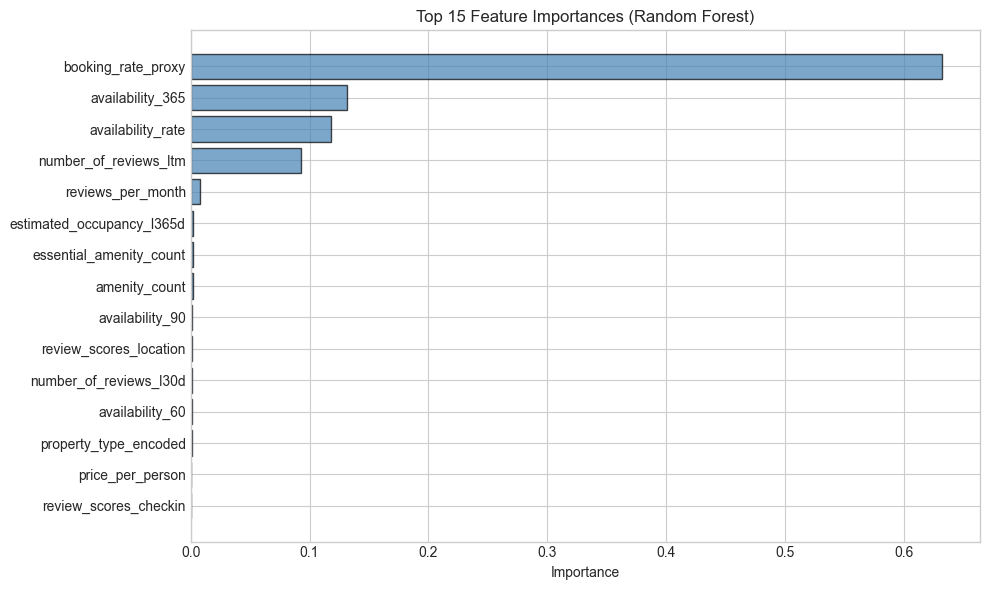

In [27]:
# Feature importance from RF
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': random_search.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

print('\nTop 15 Feature Importances:')
print(importances.head(15))

# Plot
plt.figure(figsize=(10, 6))
top_15 = importances.head(15)
plt.barh(range(len(top_15)), top_15['importance'].values, color='steelblue', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_15)), top_15['feature'].values)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Test Set Evaluation

In [28]:
# Using best model
if best_name == 'Neural Network':
    X_test_scaled = scaler.transform(X_test)
    y_test_pred = best_model.predict(X_test_scaled)
else:
    y_test_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
mape = np.mean(np.abs((y_test - y_test_pred) / (y_test + 1))) * 100

print(f'Best Model: {best_name}')
print(f'Test Metrics:')
print(f'RMSE: {rmse_test:.2f}')
print(f'MAE:  {mae_test:.2f}')
print(f'R2:   {r2_test:.3f}')
print(f'MAPE: {mape:.2f}%')

Best Model: Random Forest (Baseline)
Test Metrics:
RMSE: 7.62
MAE:  0.79
R2:   0.981
MAPE: 0.78%


### Prediction Visualization

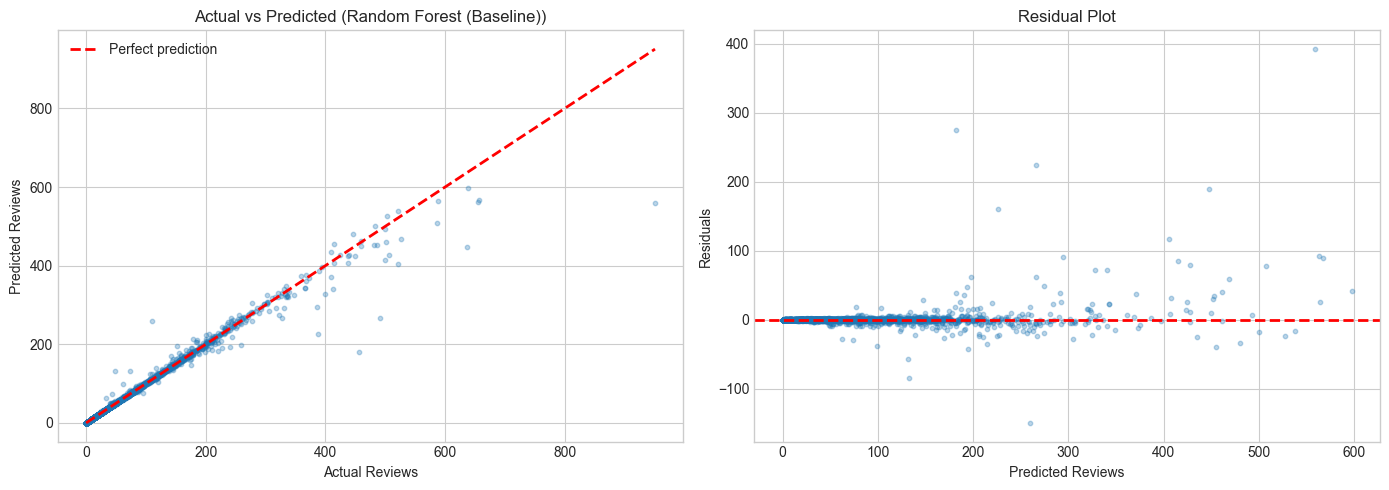

In [29]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_test_pred, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Perfect prediction')
axes[0].set(xlabel='Actual Reviews', ylabel='Predicted Reviews',
           title=f'Actual vs Predicted ({best_name})')
axes[0].legend()

# Residuals
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1].set(xlabel='Predicted Reviews', ylabel='Residuals',
           title='Residual Plot')

plt.tight_layout()
plt.show()

### Saving Best Model

In [30]:
import joblib

# Saving model
joblib.dump(best_model, f'models/demand_model_{best_name.replace(" ", "_").lower()}.pkl')
print(f'Saved: demand_model_{best_name.replace(" ", "_").lower()}.pkl')

# Saving scaler if NN is best model
if best_name == 'Neural Network':
    joblib.dump(scaler, 'models/demand_scaler.pkl')

# Saving feature list
with open('models/demand_features.txt', 'w') as f:
    for feat in feature_cols:
        f.write(f'{feat}\n')

# Saving metrics
metrics = {
    'model': best_name,
    'test_rmse': rmse_test,
    'test_mae': mae_test,
    'test_r2': r2_test,
    'test_mape': mape
}

import json
with open('outputs/demand_model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

Saved: demand_model_random_forest_(baseline).pkl


### Summary

In [31]:
print(f'\nModels Compared:')
print(f'  1. Linear Regression:  RMSE={rmse:.2f}, R2={r2:.3f}')
print(f'  2. Random Forest:      RMSE={rmse_val_tuned:.2f}, R2={r2_rf:.3f}')
print(f'  3. Neural Network:     RMSE={rmse_nn:.2f}, R2={r2_nn:.3f}')
print(f'\nBest Model: {best_name} ')
print(f'Test Performance: RMSE={rmse_test:.2f}, R2={r2_test:.3f}, MAPE={mape:.1f}%')
print(f'\nModel can predict demand (reviews) based on price and property features.')
print(f'Next: Will use this model in optimization to find revenue-maximizing prices.')


Models Compared:
  1. Linear Regression:  RMSE=41.93, R2=0.479
  2. Random Forest:      RMSE=8.15, R2=0.980
  3. Neural Network:     RMSE=8.86, R2=0.977

Best Model: Random Forest (Baseline) 
Test Performance: RMSE=7.62, R2=0.981, MAPE=0.8%

Model can predict demand (reviews) based on price and property features.
Next: Will use this model in optimization to find revenue-maximizing prices.
